In [4]:
!wget -q --show-progress https://www.kaggle.com/api/v1/datasets/download/paultimothymooney/chest-xray-pneumonia -O chest-xray-pneumonia.zip

chest-xray-pneumoni 100%[===================>]   2.29G  42.5MB/s    in 57s     


In [5]:
!unzip -q chest-xray-pneumonia.zip -d /content/data

In [6]:
import os

print(os.listdir('/content/data'))

['chest_xray']


In [7]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

In [8]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    '/content/data/chest_xray/train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=42
)

test_ds = image_dataset_from_directory(
    '/content/data/chest_xray/test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [9]:
class_names=train_ds.class_names
class_names

['NORMAL', 'PNEUMONIA']

In [10]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

normalization = layers.Rescaling(1./255)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Conv2D,MaxPooling2D,Dropout,Flatten

In [12]:
model=Sequential([
    Input(shape=(150,150,3)),
    data_augmentation,
    normalization,
    Conv2D(32, kernel_size=(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall')])

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    'best_pneumonia_model.keras', monitor='val_loss', save_best_only=True)

In [15]:
history = model.fit(
    train_ds,
    validation_split=0.0,
    validation_data=test_ds,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 220ms/step - accuracy: 0.7834 - loss: 0.4825 - precision: 0.8060 - recall: 0.9329 - val_accuracy: 0.8045 - val_loss: 0.4270 - val_precision: 0.7735 - val_recall: 0.9718
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 234ms/step - accuracy: 0.8855 - loss: 0.2798 - precision: 0.9122 - recall: 0.9360 - val_accuracy: 0.8750 - val_loss: 0.3417 - val_precision: 0.8697 - val_recall: 0.9410
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 216ms/step - accuracy: 0.9114 - loss: 0.2241 - precision: 0.9363 - recall: 0.9450 - val_accuracy: 0.8253 - val_loss: 0.3795 - val_precision: 0.8035 - val_recall: 0.9538
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 218ms/step - accuracy: 0.9122 - loss: 0.2219 - precision: 0.9386 - recall: 0.9435 - val_accuracy: 0.8253 - val_loss: 0.4242 - val_precision: 0.7945 - val_recall: 0.9718
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 232ms/step - accuracy: 0.9222 - loss: 0.1945 - precision: 0.9453 - recall: 0.9502 - val_accuracy: 0.8590

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 188ms/step
              precision    recall  f1-score   support

      NORMAL       0.89      0.76      0.82       234
   PNEUMONIA       0.87      0.94      0.90       390

    accuracy                           0.88       624
   macro avg       0.88      0.85      0.86       624
weighted avg       0.88      0.88      0.87       624



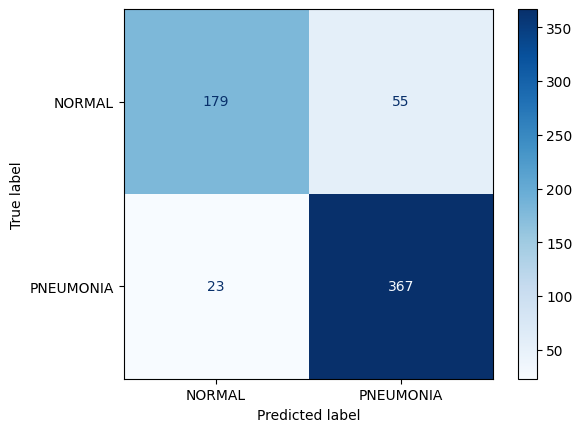

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_proba = model.predict(test_ds)
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues')

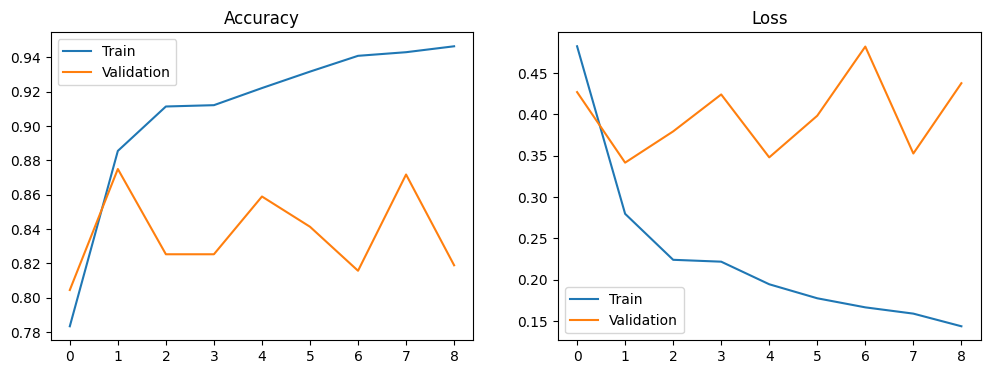

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss'); plt.legend()
plt.show()

In [18]:
model.save('pneumonia_cnn_model.keras')